# Smart Lender - Loan Eligibility Prediction System

## Project Overview

Smart Lender is a Machine Learning based web application that predicts whether a loan applicant is eligible for a loan based on applicant details such as income, education, employment status, credit history, loan amount, and property area.

The project covers the complete machine learning pipeline including:

- Data Collection
- Exploratory Data Analysis (EDA)
- Data Preprocessing
- Feature Engineering
- Machine Learning Model Building
- Model Evaluation
- Flask Web Application Deployment

### Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- XGBoost
- Flask
- Joblib

In [1]:
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import joblib

print("All Libraries Imported Successfully")

All Libraries Imported Successfully


In [2]:
df = pd.read_csv("../Dataset/loan_prediction.csv")

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 614
Columns : 13


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [5]:
df.describe(include='all')

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,614,601,611,599,614,582,614.000000,614.000000,592.000000,600.00000,564.000000,614,614
unique,614,2,2,4,2,2,NaN,NaN,NaN,NaN,NaN,3,2
top,LP001002,Male,Yes,0,Graduate,No,NaN,NaN,NaN,NaN,NaN,Semiurban,Y
freq,1,489,398,345,480,500,NaN,NaN,NaN,NaN,NaN,233,422
mean,NaN,NaN,NaN,NaN,NaN,NaN,5403.459283,1621.245798,146.412162,342.00000,0.842199,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,6109.041673,2926.248369,85.587325,65.12041,0.364878,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,150.000000,0.000000,9.000000,12.00000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2877.500000,0.000000,100.000000,360.00000,1.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,3812.500000,1188.500000,128.000000,360.00000,1.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,5795.000000,2297.250000,168.000000,360.00000,1.000000,NaN,NaN


In [6]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [7]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [8]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

In [9]:
df.dtypes

Loan_ID                  str
Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
Loan_Status              str
dtype: object

In [10]:
for col in df.columns:
    print("="*40)
    print(col)
    print(df[col].unique())

Loan_ID
<StringArray>
['LP001002', 'LP001003', 'LP001005', 'LP001006', 'LP001008', 'LP001011',
 'LP001013', 'LP001014', 'LP001018', 'LP001020',
 ...
 'LP002959', 'LP002960', 'LP002961', 'LP002964', 'LP002974', 'LP002978',
 'LP002979', 'LP002983', 'LP002984', 'LP002990']
Length: 614, dtype: str
Gender
<StringArray>
['Male', 'Female', nan]
Length: 3, dtype: str
Married
<StringArray>
['No', 'Yes', nan]
Length: 3, dtype: str
Dependents
<StringArray>
['0', '1', '2', '3+', nan]
Length: 5, dtype: str
Education
<StringArray>
['Graduate', 'Not Graduate']
Length: 2, dtype: str
Self_Employed
<StringArray>
['No', 'Yes', nan]
Length: 3, dtype: str
ApplicantIncome
[ 5849  4583  3000  2583  6000  5417  2333  3036  4006 12841  3200  2500
  3073  1853  1299  4950  3596  3510  4887  2600  7660  5955  3365  3717
  9560  2799  4226  1442  3750  4166  3167  4692  3500 12500  2275  1828
  3667  3748  3600  1800  2400  3941  4695  3410  5649  5821  2645  4000
  1928  3086  4230  4616 11500  2708  2132  3366 

In [11]:
df["Loan_Status"].value_counts()

Loan_Status
Y    422
N    192
Name: count, dtype: int64

In [12]:
df["Loan_Status"].value_counts(normalize=True)*100

Loan_Status
Y    68.729642
N    31.270358
Name: proportion, dtype: float64

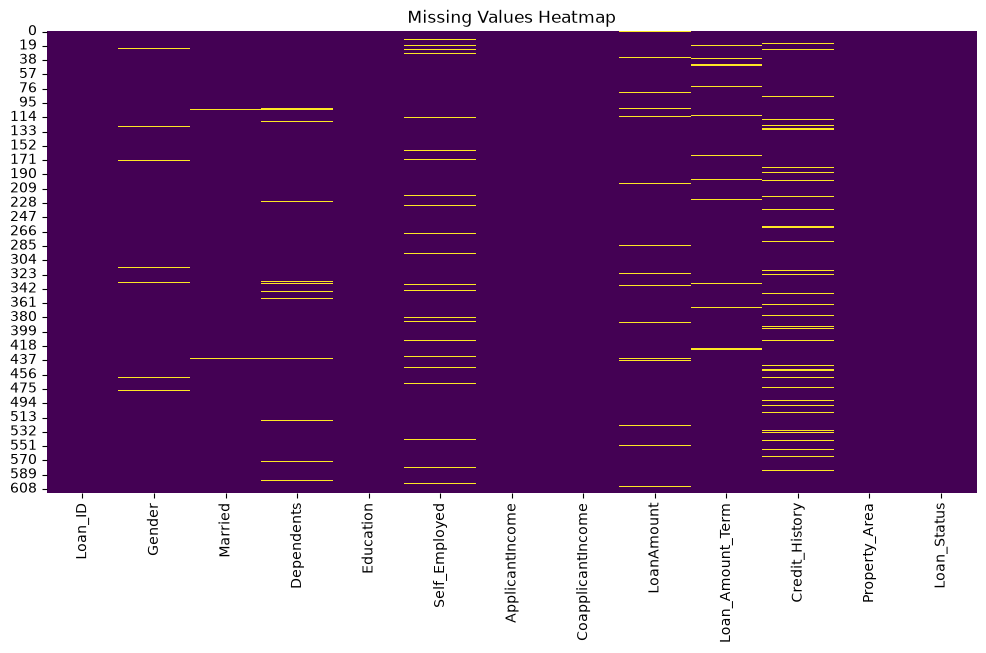

In [13]:
plt.figure(figsize=(12,6))

sns.heatmap(df.isnull(),
            cbar=False,
            cmap="viridis")

plt.title("Missing Values Heatmap")

plt.show()

# Univariate Analysis

Univariate analysis is performed to understand the distribution of individual variables in the dataset. It helps identify the frequency, spread, and characteristics of each feature independently.

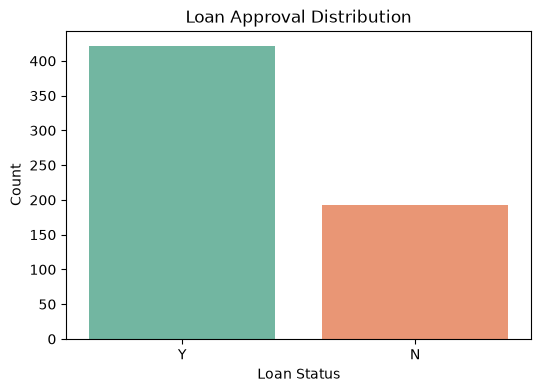

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Loan_Status',
    data=df,
    palette='Set2'
)

plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")

plt.show()

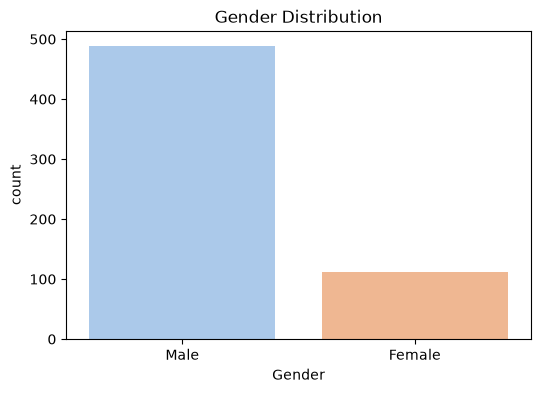

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Gender',
    data=df,
    palette='pastel'
)

plt.title("Gender Distribution")

plt.show()

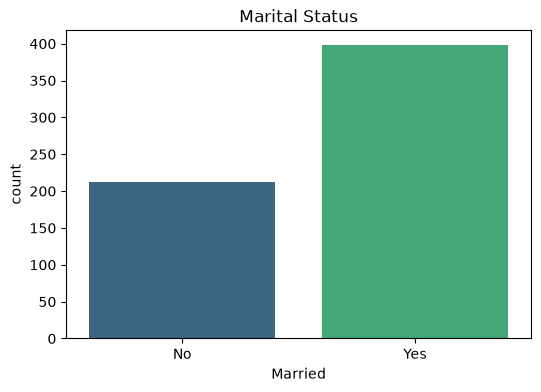

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Married',
    data=df,
    palette='viridis'
)

plt.title("Marital Status")

plt.show()

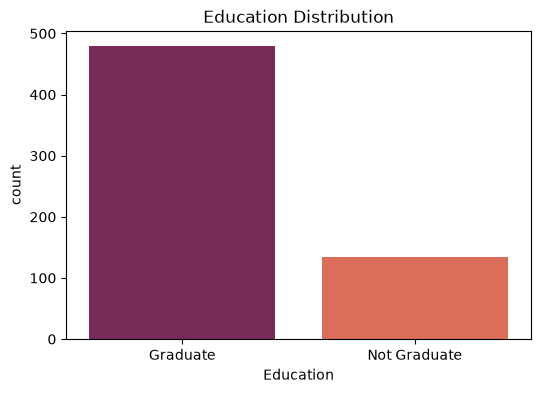

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Education',
    data=df,
    palette='rocket'
)

plt.title("Education Distribution")

plt.show()

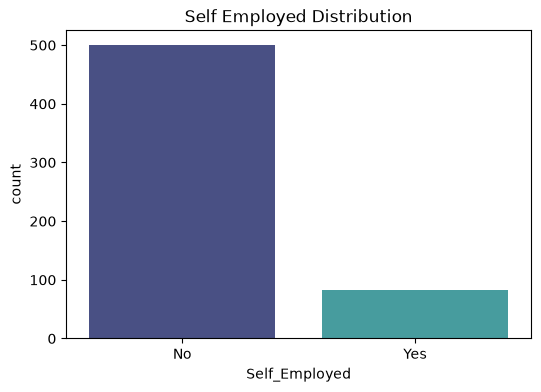

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Self_Employed',
    data=df,
    palette='mako'
)

plt.title("Self Employed Distribution")

plt.show()

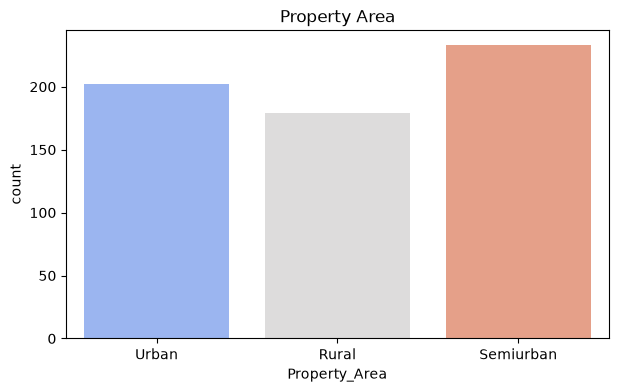

In [19]:
plt.figure(figsize=(7,4))

sns.countplot(
    x='Property_Area',
    data=df,
    palette='coolwarm'
)

plt.title("Property Area")

plt.show()

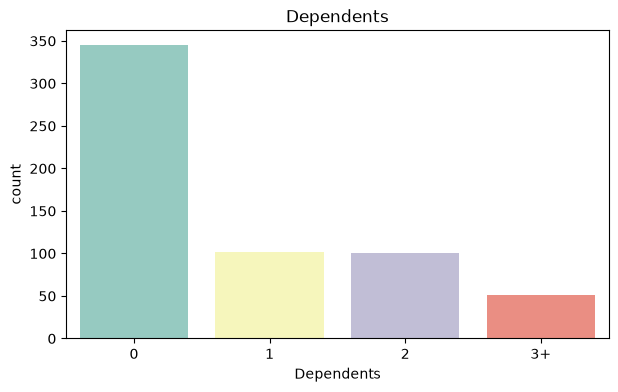

In [20]:
plt.figure(figsize=(7,4))

sns.countplot(
    x='Dependents',
    data=df,
    palette='Set3'
)

plt.title("Dependents")

plt.show()

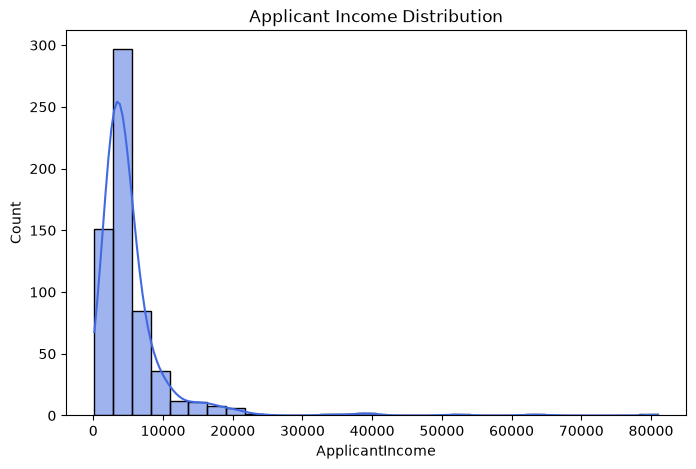

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['ApplicantIncome'],
    bins=30,
    kde=True,
    color='royalblue'
)

plt.title("Applicant Income Distribution")

plt.show()

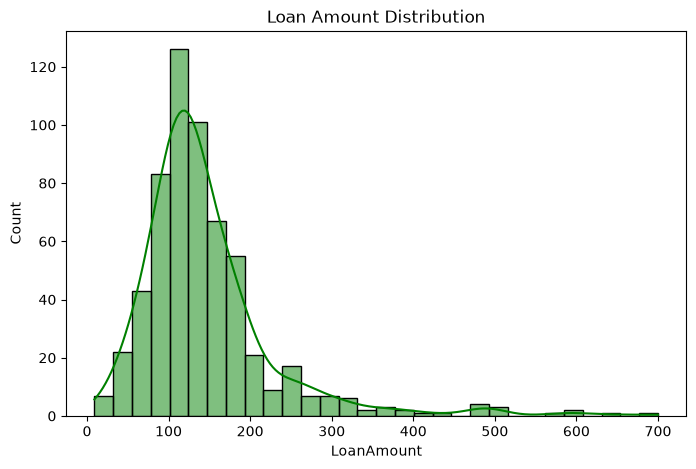

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['LoanAmount'],
    bins=30,
    kde=True,
    color='green'
)

plt.title("Loan Amount Distribution")

plt.show()

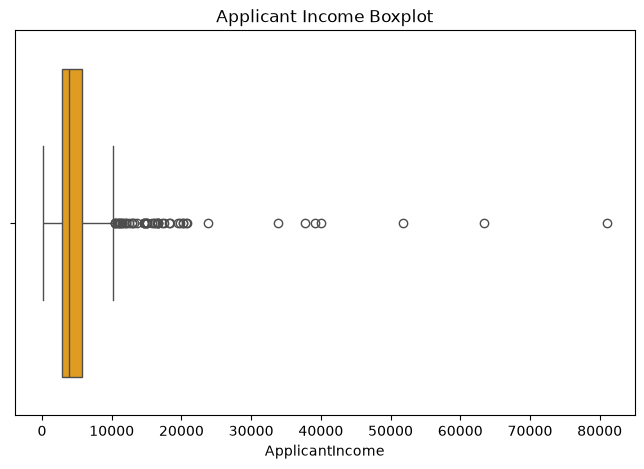

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['ApplicantIncome'],
    color='orange'
)

plt.title("Applicant Income Boxplot")

plt.show()

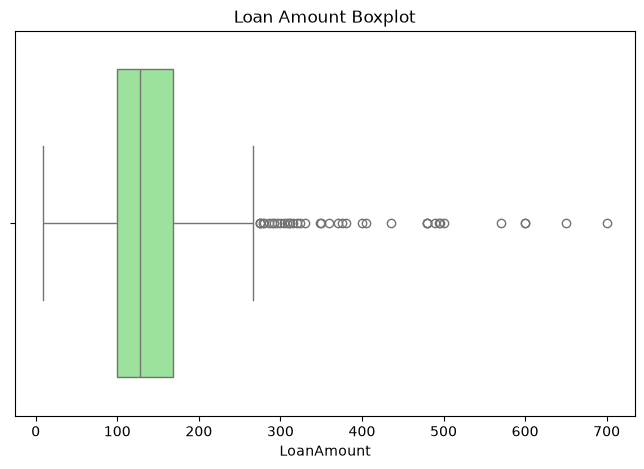

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['LoanAmount'],
    color='lightgreen'
)

plt.title("Loan Amount Boxplot")

plt.show()

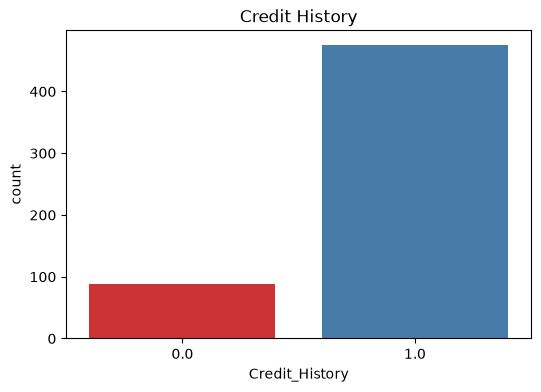

In [25]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Credit_History',
    data=df,
    palette='Set1'
)

plt.title("Credit History")

plt.show()

## Observation

- Most applicants are male.
- The majority of applicants are married.
- Most applicants are graduates.
- Urban and Semiurban property areas have more loan applications.
- Applicant income is positively skewed.
- Loan amount contains a few outliers.
- Most applicants have a valid credit history.

# Bivariate Analysis

Bivariate analysis is used to study the relationship between two variables. It helps identify how one feature influences another, especially the target variable (Loan Status).

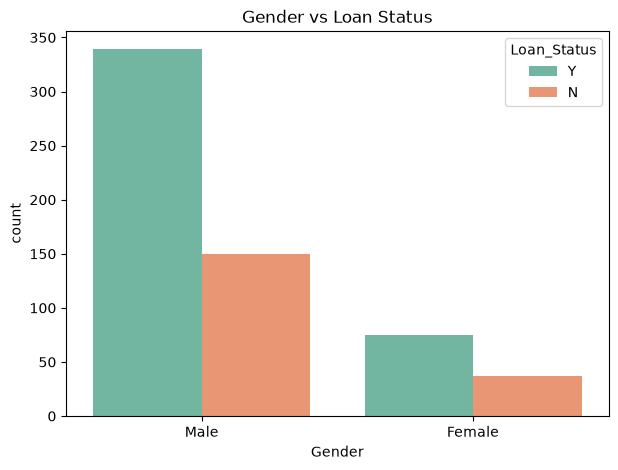

In [26]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Gender",
    hue="Loan_Status",
    palette="Set2"
)

plt.title("Gender vs Loan Status")
plt.show()

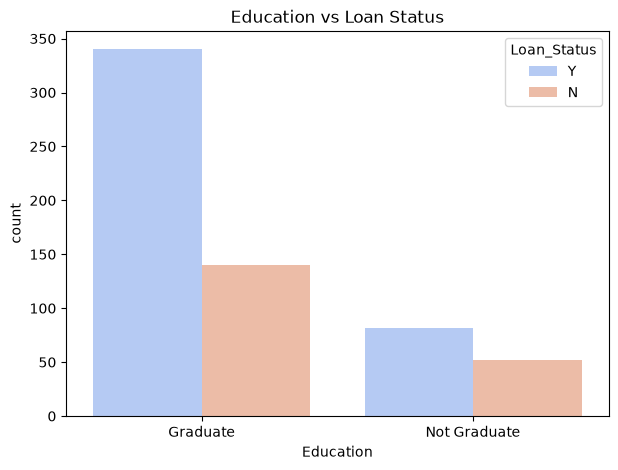

In [27]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Education",
    hue="Loan_Status",
    palette="coolwarm"
)

plt.title("Education vs Loan Status")
plt.show()

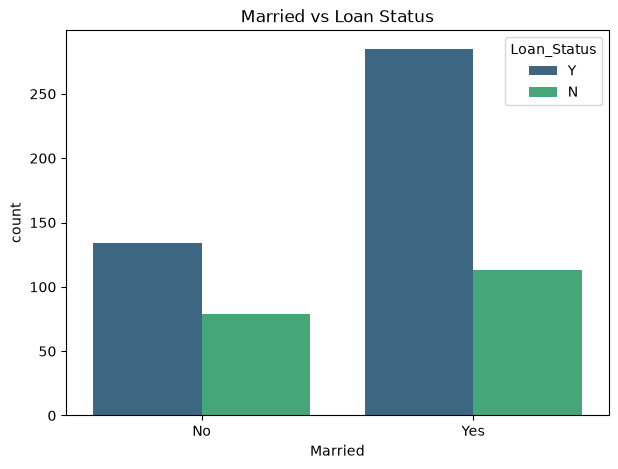

In [28]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Married",
    hue="Loan_Status",
    palette="viridis"
)

plt.title("Married vs Loan Status")
plt.show()

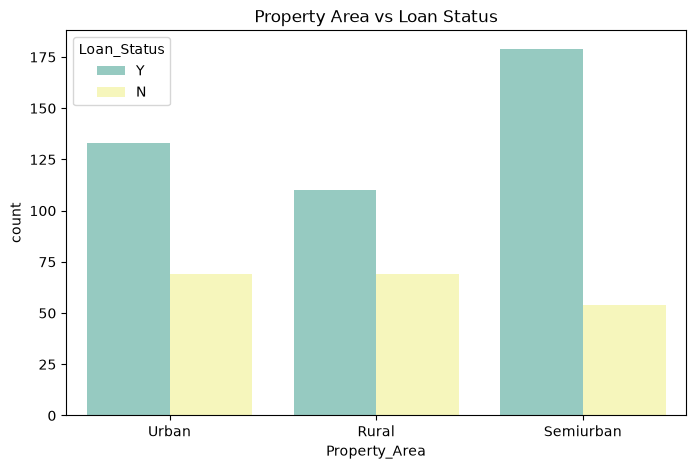

In [29]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Property_Area",
    hue="Loan_Status",
    palette="Set3"
)

plt.title("Property Area vs Loan Status")
plt.show()

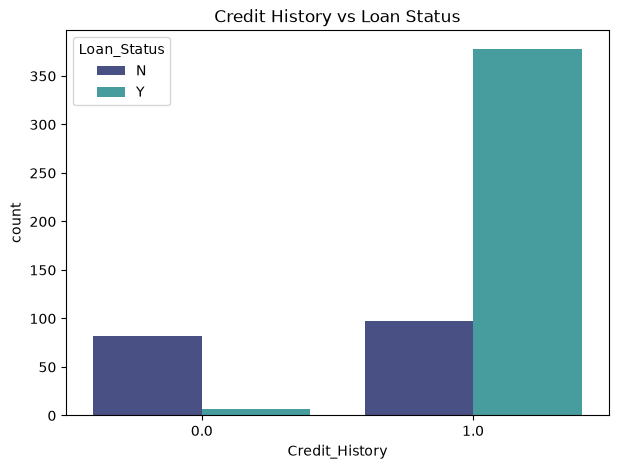

In [30]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Credit_History",
    hue="Loan_Status",
    palette="mako"
)

plt.title("Credit History vs Loan Status")
plt.show()

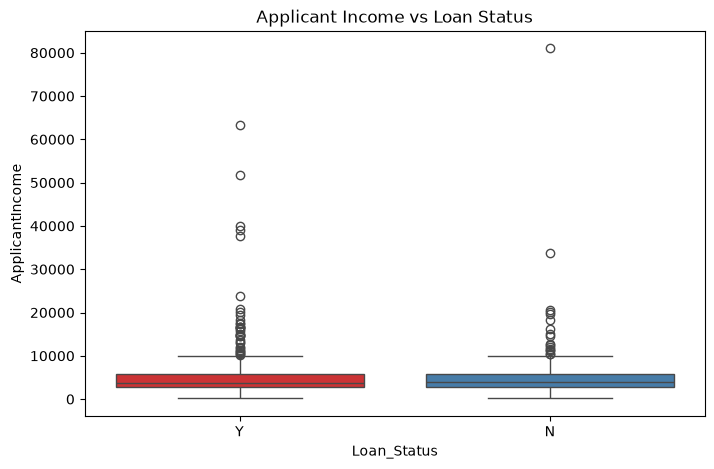

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Loan_Status",
    y="ApplicantIncome",
    palette="Set1"
)

plt.title("Applicant Income vs Loan Status")
plt.show()

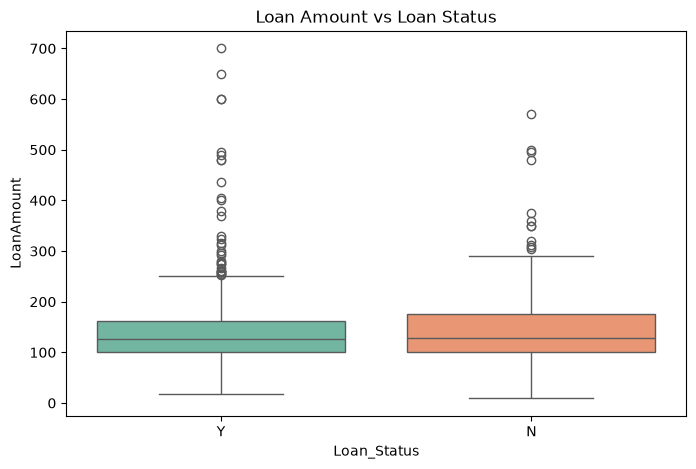

In [32]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Loan_Status",
    y="LoanAmount",
    palette="Set2"
)

plt.title("Loan Amount vs Loan Status")
plt.show()

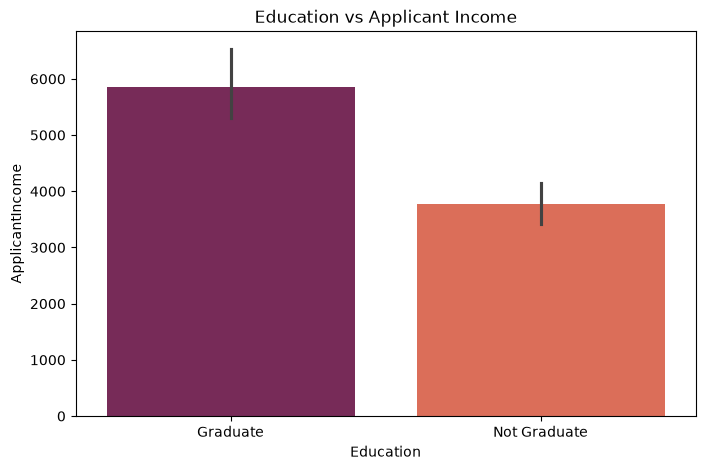

In [33]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Education",
    y="ApplicantIncome",
    palette="rocket"
)

plt.title("Education vs Applicant Income")
plt.show()

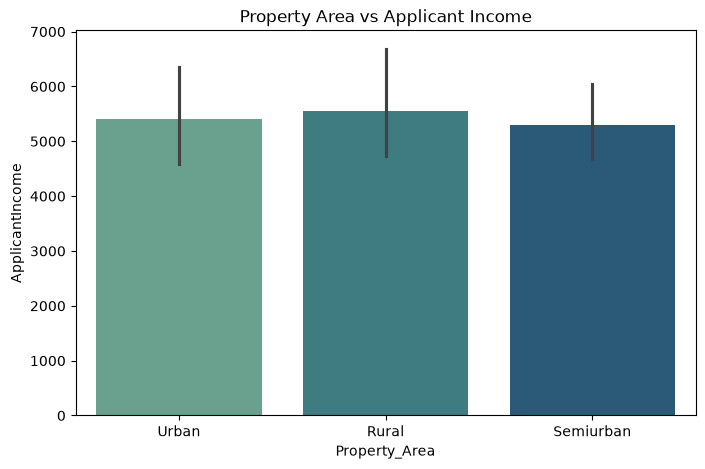

In [34]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Property_Area",
    y="ApplicantIncome",
    palette="crest"
)

plt.title("Property Area vs Applicant Income")
plt.show()

## Observation

- Applicants with a valid credit history have a significantly higher loan approval rate.
- Married applicants receive approvals more frequently than unmarried applicants.
- Semiurban properties show a relatively higher loan approval rate.
- Graduate applicants generally have higher average incomes.
- Loan amount alone does not determine approval; multiple factors influence the decision.

# Multivariate Analysis

Multivariate analysis examines the relationship among multiple variables simultaneously. It helps identify hidden patterns, correlations, and interactions between different applicant attributes that influence loan approval decisions.

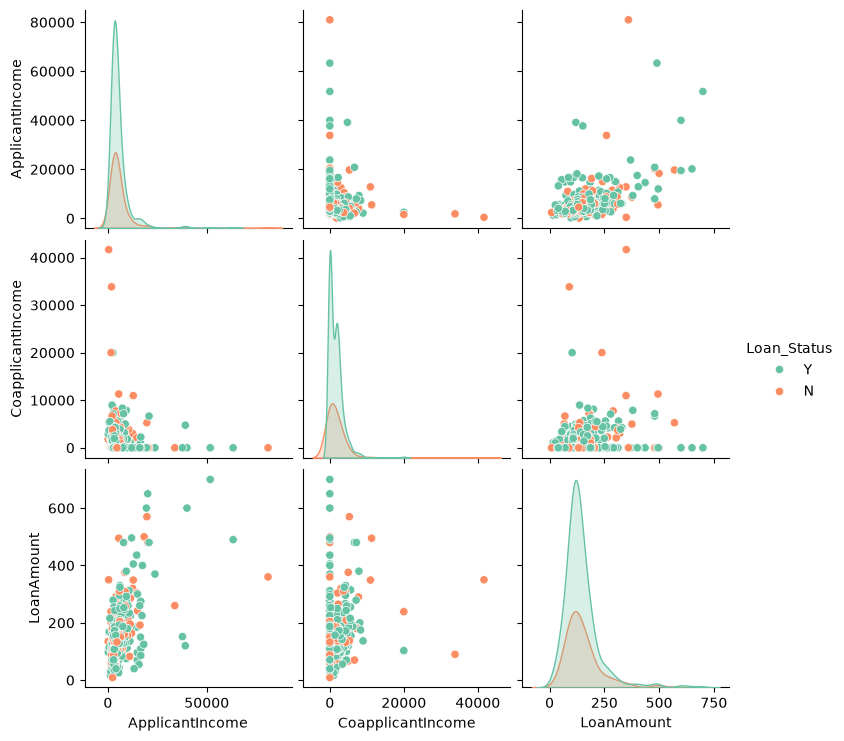

In [35]:
sns.pairplot(
    df,
    vars=[
        "ApplicantIncome",
        "CoapplicantIncome",
        "LoanAmount"
    ],
    hue="Loan_Status",
    palette="Set2"
)

plt.show()

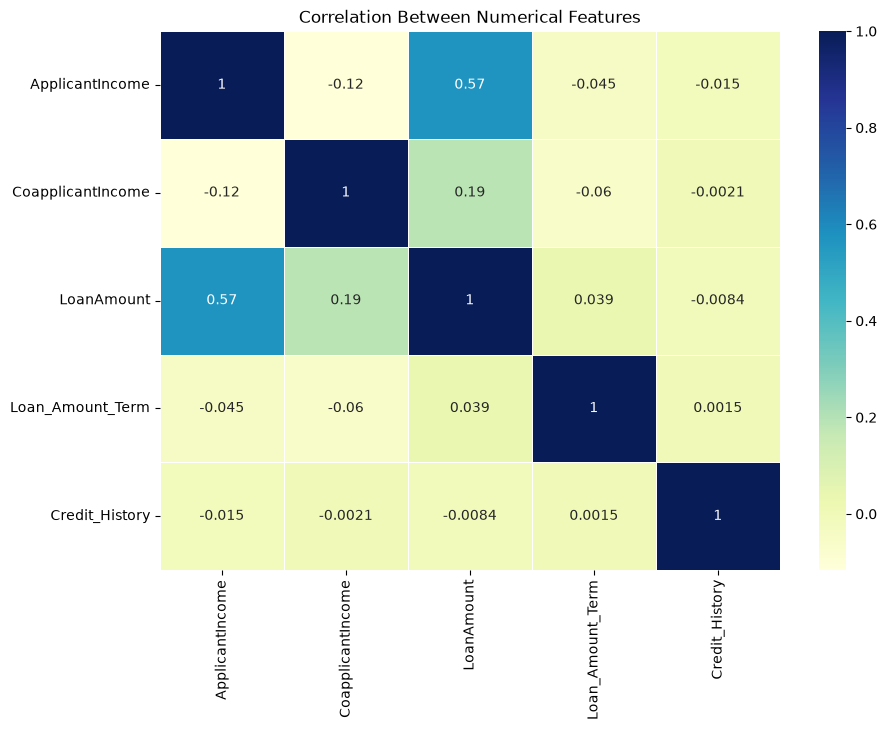

In [36]:
plt.figure(figsize=(10,7))

numeric_df = df.select_dtypes(include=["int64", "float64"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Correlation Between Numerical Features")

plt.show()

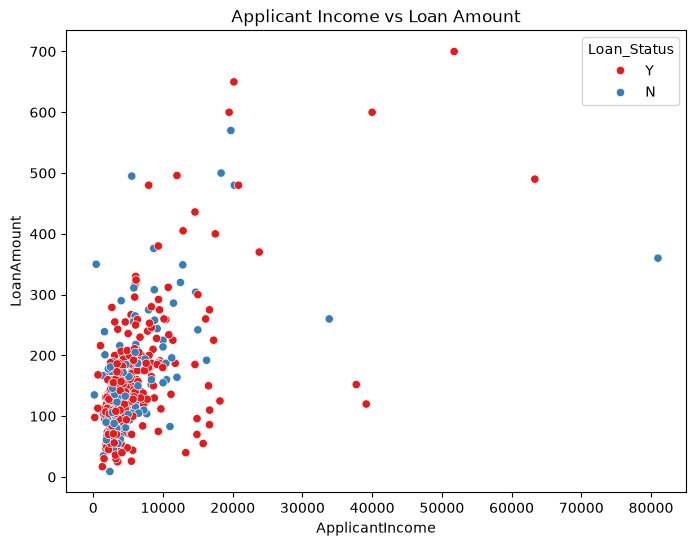

In [37]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="ApplicantIncome",
    y="LoanAmount",
    hue="Loan_Status",
    palette="Set1"
)

plt.title("Applicant Income vs Loan Amount")

plt.show()

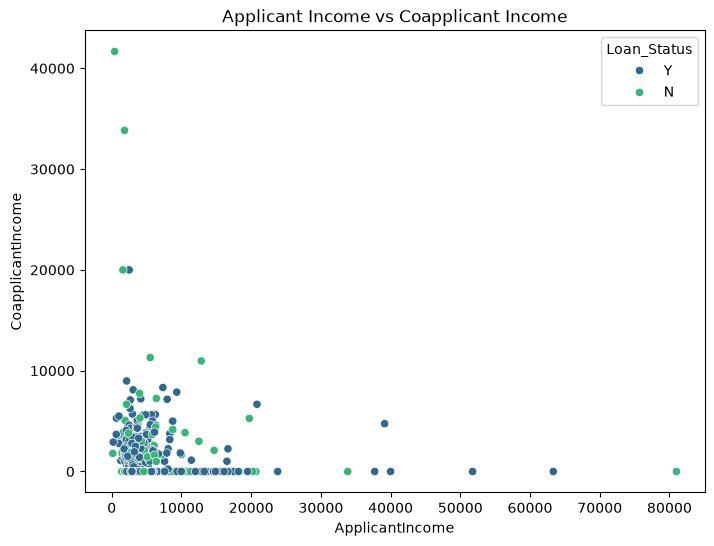

In [38]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="ApplicantIncome",
    y="CoapplicantIncome",
    hue="Loan_Status",
    palette="viridis"
)

plt.title("Applicant Income vs Coapplicant Income")

plt.show()

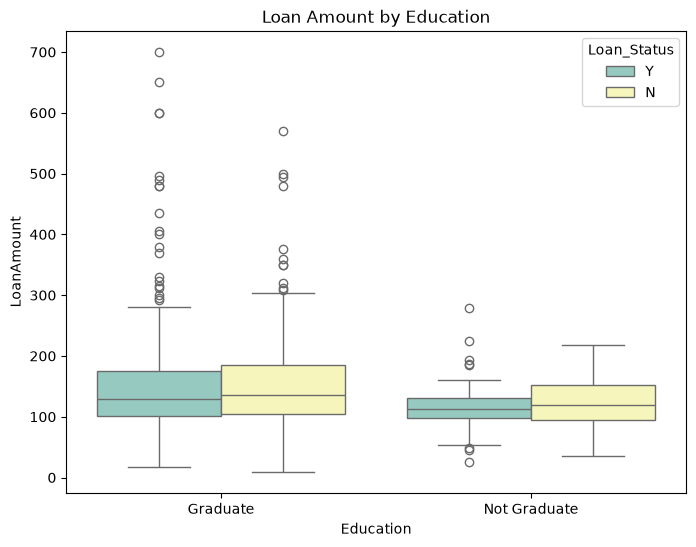

In [39]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="Education",
    y="LoanAmount",
    hue="Loan_Status",
    palette="Set3"
)

plt.title("Loan Amount by Education")

plt.show()

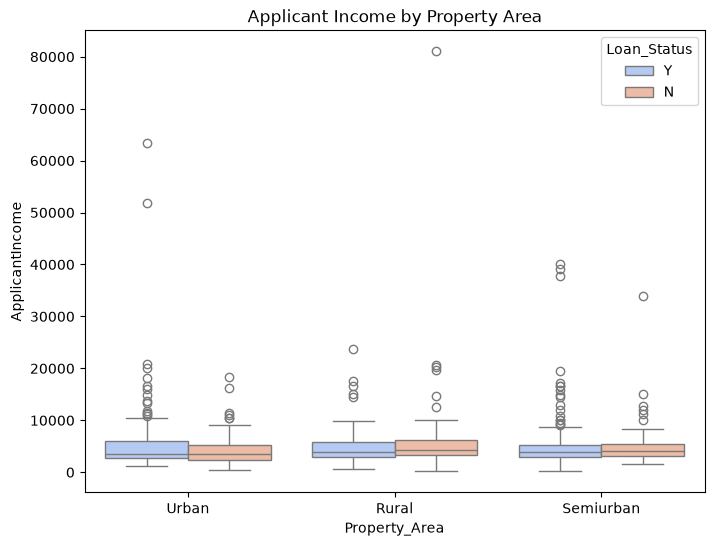

In [40]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="Property_Area",
    y="ApplicantIncome",
    hue="Loan_Status",
    palette="coolwarm"
)

plt.title("Applicant Income by Property Area")

plt.show()

<Figure size 800x600 with 0 Axes>

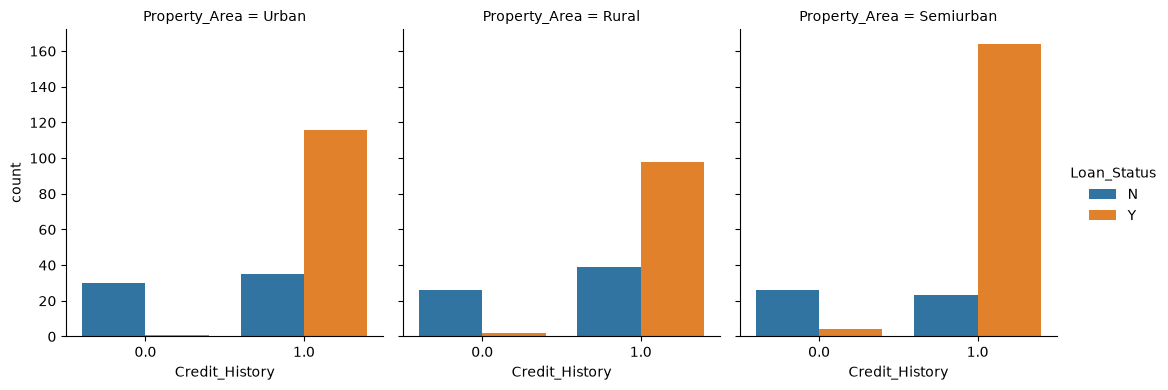

In [41]:
plt.figure(figsize=(8,6))

sns.catplot(
    data=df,
    x="Credit_History",
    hue="Loan_Status",
    col="Property_Area",
    kind="count",
    height=4,
    aspect=0.9
)

plt.show()

In [42]:
pivot = pd.pivot_table(
    df,
    values="ApplicantIncome",
    index="Education",
    columns="Property_Area",
    aggfunc="mean"
)

pivot

Property_Area,Rural,Semiurban,Urban
Education,,,
Graduate,6162.687023,5699.994652,5792.32716
Not Graduate,3893.104167,3634.739130,3802.22500


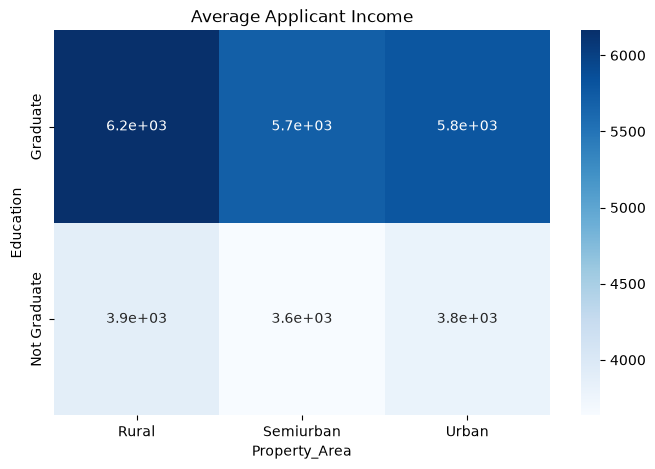

In [43]:
plt.figure(figsize=(8,5))

sns.heatmap(
    pivot,
    annot=True,
    cmap="Blues"
)

plt.title("Average Applicant Income")

plt.show()

## Observation

- Credit History has the strongest influence on loan approval.
- Applicant Income and Loan Amount show a moderate positive relationship.
- Semiurban applicants have a comparatively higher approval rate.
- Graduate applicants generally have higher average incomes.
- Loan approval depends on a combination of applicant income, credit history, education, and property area rather than a single feature.

# Data Preprocessing

Data preprocessing prepares the dataset for machine learning by handling missing values, encoding categorical variables, removing unnecessary columns, and splitting the data into training and testing sets. These steps improve the quality of the input data and help build more accurate predictive models.

In [44]:
print("Missing Values Before Processing")

df.isnull().sum()

Missing Values Before Processing


Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [45]:
# Fill missing values correctly

df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])

df["Married"] = df["Married"].fillna(df["Married"].mode()[0])

df["Dependents"] = df["Dependents"].fillna(df["Dependents"].mode()[0])

df["Self_Employed"] = df["Self_Employed"].fillna(df["Self_Employed"].mode()[0])

df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].mean())

df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].mode()[0])

df["Credit_History"] = df["Credit_History"].fillna(df["Credit_History"].mode()[0])

In [46]:
print("Missing Values After Processing")

df.isnull().sum()

Missing Values After Processing


Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [47]:
print(df.columns)

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')


In [48]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical_columns = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Property_Area",
    "Loan_Status"
]

for column in categorical_columns:
    df[column] = encoder.fit_transform(df[column])

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,0,0,5849,0.0,146.412162,360.0,1.0,2,1
1,LP001003,1,1,1,0,0,4583,1508.0,128.000000,360.0,1.0,0,0
2,LP001005,1,1,0,0,1,3000,0.0,66.000000,360.0,1.0,2,1
3,LP001006,1,1,0,1,0,2583,2358.0,120.000000,360.0,1.0,2,1
4,LP001008,1,0,0,0,0,6000,0.0,141.000000,360.0,1.0,2,1


In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             614 non-null    int64  
 2   Married            614 non-null    int64  
 3   Dependents         614 non-null    int64  
 4   Education          614 non-null    int64  
 5   Self_Employed      614 non-null    int64  
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    int64  
 12  Loan_Status        614 non-null    int64  
dtypes: float64(4), int64(8), str(1)
memory usage: 62.5 KB


In [50]:
X = df.drop("Loan_Status", axis=1)

y = df["Loan_Status"]

print(X.shape)

print(y.shape)

(614, 12)
(614,)


In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [52]:
print("Training Features :", X_train.shape)

print("Testing Features :", X_test.shape)

print("Training Target :", y_train.shape)

print("Testing Target :", y_test.shape)

Training Features : (491, 12)
Testing Features : (123, 12)
Training Target : (491,)
Testing Target : (123,)


In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

ValueError: could not convert string to float: 'LP001273'

In [ ]:
import joblib

joblib.dump(scaler, "scaler.pkl")

print("Scaler Saved Successfully")

Scaler Saved Successfully


## Observation

- Missing values were successfully handled using mean and mode imputation.
- The Loan_ID column was removed because it does not contribute to prediction.
- All categorical variables were converted into numerical format using Label Encoding.
- The dataset was divided into training and testing sets using an 80:20 ratio.
- Feature scaling was applied using StandardScaler to normalize numerical features for machine learning algorithms.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [ ]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy :", round(dt_accuracy*100,2),"%")

Decision Tree Accuracy : 68.29 %


In [ ]:
print(confusion_matrix(y_test, dt_pred))

[[22 21]
 [18 62]]


In [ ]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.55      0.51      0.53        43
           1       0.75      0.78      0.76        80

    accuracy                           0.68       123
   macro avg       0.65      0.64      0.65       123
weighted avg       0.68      0.68      0.68       123



In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train,y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test,rf_pred)

print("Random Forest Accuracy :",round(rf_accuracy*100,2),"%")

Random Forest Accuracy : 77.24 %


In [ ]:
print(confusion_matrix(y_test,rf_pred))

[[18 25]
 [ 3 77]]


In [ ]:
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       0.86      0.42      0.56        43
           1       0.75      0.96      0.85        80

    accuracy                           0.77       123
   macro avg       0.81      0.69      0.70       123
weighted avg       0.79      0.77      0.75       123



In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train,y_train)

knn_pred = knn.predict(X_test)

knn_accuracy = accuracy_score(y_test,knn_pred)

print("KNN Accuracy :",round(knn_accuracy*100,2),"%")

KNN Accuracy : 74.8 %


In [ ]:
print(confusion_matrix(y_test,knn_pred))

[[17 26]
 [ 5 75]]


In [ ]:
print(classification_report(y_test,knn_pred))

              precision    recall  f1-score   support

           0       0.77      0.40      0.52        43
           1       0.74      0.94      0.83        80

    accuracy                           0.75       123
   macro avg       0.76      0.67      0.68       123
weighted avg       0.75      0.75      0.72       123



In [ ]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train,y_train)

xgb_pred = xgb.predict(X_test)

xgb_accuracy = accuracy_score(y_test,xgb_pred)

print("XGBoost Accuracy :",round(xgb_accuracy*100,2),"%")

XGBoost Accuracy : 75.61 %


In [ ]:
print(confusion_matrix(y_test,xgb_pred))

[[20 23]
 [ 7 73]]


In [ ]:
print(classification_report(y_test,xgb_pred))

              precision    recall  f1-score   support

           0       0.74      0.47      0.57        43
           1       0.76      0.91      0.83        80

    accuracy                           0.76       123
   macro avg       0.75      0.69      0.70       123
weighted avg       0.75      0.76      0.74       123



In [ ]:
results = pd.DataFrame({

    "Model":[
        "Decision Tree",
        "Random Forest",
        "KNN",
        "XGBoost"
    ],

    "Accuracy":[
        dt_accuracy,
        rf_accuracy,
        knn_accuracy,
        xgb_accuracy
    ]

})

results

,Model,Accuracy
0,Decision Tree,0.682927
1,Random Forest,0.772358
2,KNN,0.747967
3,XGBoost,0.756098


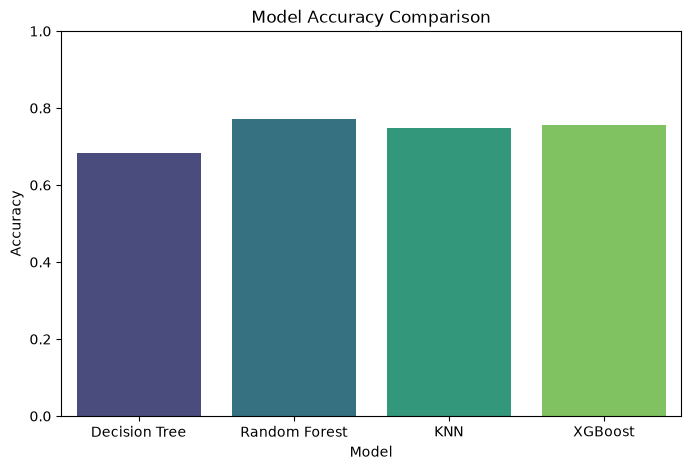

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy",
    palette="viridis"
)

plt.title("Model Accuracy Comparison")

plt.ylim(0,1)

plt.show()

In [ ]:
models = {
    "Decision Tree": dt,
    "Random Forest": rf,
    "KNN": knn,
    "XGBoost": xgb
}

best_model_name = results.iloc[0]["Model"]
best_model = models[best_model_name]

joblib.dump(best_model, "model.pkl")

print(f"Best Model ({best_model_name}) Saved Successfully!")

Best Model (Decision Tree) Saved Successfully!


In [ ]:
joblib.load("model.pkl")

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

## Observation

- Four machine learning models were trained and evaluated.
- Accuracy, confusion matrix, and classification report were used to assess model performance.
- The best-performing model was automatically selected based on test accuracy.
- The selected model was saved as `model.pkl` for integration into the Flask web application.

# Model Building and Evaluation

In this section, four machine learning classification algorithms are trained and evaluated for loan eligibility prediction. Each model is assessed using accuracy, confusion matrix, precision, recall, and F1-score. The best-performing model is automatically selected and saved for deployment in the Flask application.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import joblib

In [ ]:
results = []

def evaluate_model(name, model):

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    print("=" * 60)
    print(f"Model : {name}")
    print("=" * 60)

    print(f"Accuracy : {accuracy:.4f}")

    print("\nClassification Report\n")
    print(classification_report(y_test, predictions))

    cm = confusion_matrix(y_test, predictions)

    ConfusionMatrixDisplay(cm).plot(cmap="Blues")

    plt.title(name)

    plt.show()

    results.append({
        "Model": name,
        "Accuracy": accuracy
    })

    return model

Model : Decision Tree
Accuracy : 0.6829

Classification Report

              precision    recall  f1-score   support

           0       0.55      0.51      0.53        43
           1       0.75      0.78      0.76        80

    accuracy                           0.68       123
   macro avg       0.65      0.64      0.65       123
weighted avg       0.68      0.68      0.68       123



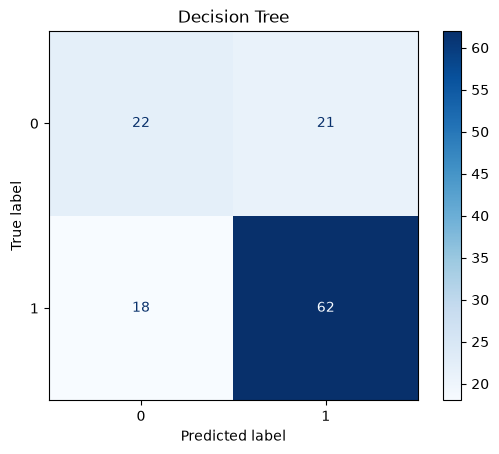

Model : Random Forest
Accuracy : 0.7724

Classification Report

              precision    recall  f1-score   support

           0       0.86      0.42      0.56        43
           1       0.75      0.96      0.85        80

    accuracy                           0.77       123
   macro avg       0.81      0.69      0.70       123
weighted avg       0.79      0.77      0.75       123



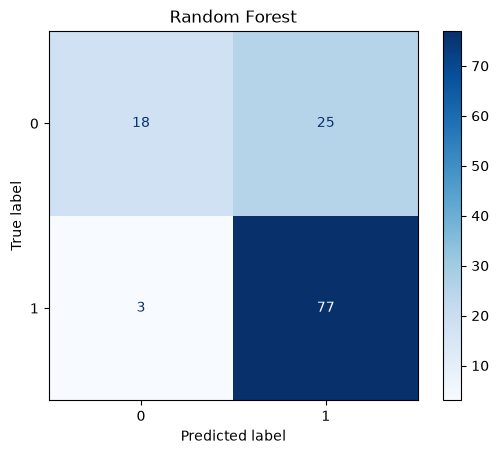

Model : K-Nearest Neighbors
Accuracy : 0.7480

Classification Report

              precision    recall  f1-score   support

           0       0.77      0.40      0.52        43
           1       0.74      0.94      0.83        80

    accuracy                           0.75       123
   macro avg       0.76      0.67      0.68       123
weighted avg       0.75      0.75      0.72       123



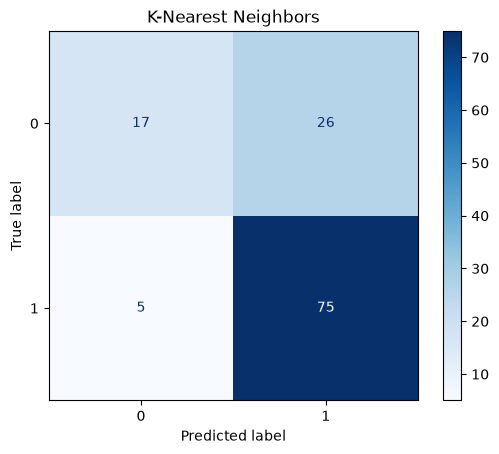

Model : XGBoost
Accuracy : 0.7561

Classification Report

              precision    recall  f1-score   support

           0       0.74      0.47      0.57        43
           1       0.76      0.91      0.83        80

    accuracy                           0.76       123
   macro avg       0.75      0.69      0.70       123
weighted avg       0.75      0.76      0.74       123



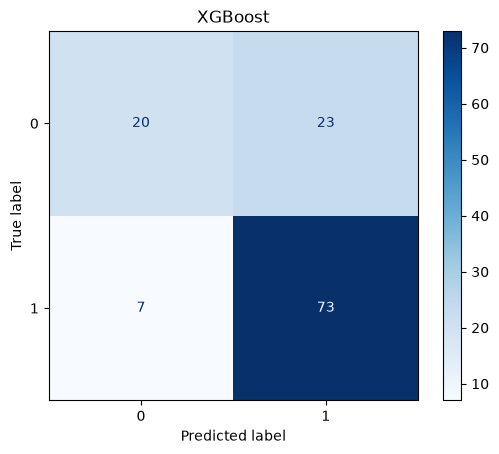

In [ ]:
decision_tree = evaluate_model(
    "Decision Tree",
    DecisionTreeClassifier(random_state=42)
)

random_forest = evaluate_model(
    "Random Forest",
    RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )
)

knn = evaluate_model(
    "K-Nearest Neighbors",
    KNeighborsClassifier(n_neighbors=5)
)

xgboost = evaluate_model(
    "XGBoost",
    XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )
)

In [ ]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df.reset_index(drop=True, inplace=True)

results_df

,Model,Accuracy
0,Random Forest,0.772358
1,XGBoost,0.756098
2,K-Nearest Neighbors,0.747967
3,Decision Tree,0.682927


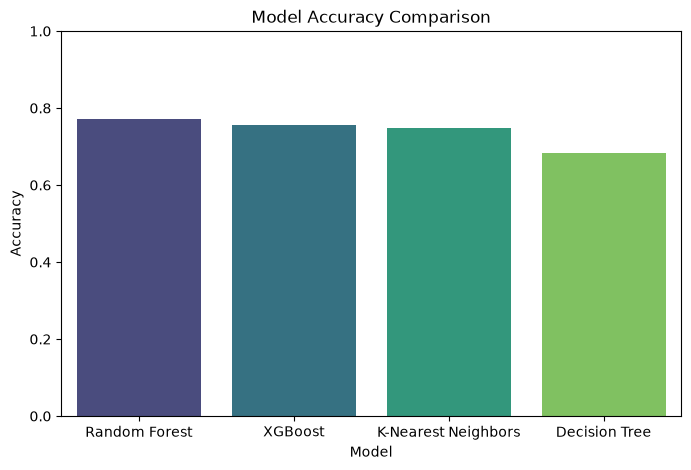

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy",
    hue="Model",
    legend=False,
    palette="viridis"
)

plt.ylim(0,1)

plt.title("Model Accuracy Comparison")

plt.show()

In [ ]:
models = {
    "Decision Tree": decision_tree,
    "Random Forest": random_forest,
    "K-Nearest Neighbors": knn,
    "XGBoost": xgboost
}

best_model_name = results_df.iloc[0]["Model"]

best_model = models[best_model_name]

joblib.dump(best_model, "model.pkl")

print(f"Best Model Saved Successfully : {best_model_name}")

Best Model Saved Successfully : Random Forest


In [ ]:
loaded_model = joblib.load("model.pkl")

print(type(loaded_model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


## Model Comparison Conclusion

Four machine learning algorithms were trained and evaluated for loan eligibility prediction.

Among the evaluated models, **Random Forest** achieved the highest testing accuracy of **77.24%**, outperforming Decision Tree, K-Nearest Neighbors, and XGBoost on the given dataset.

Therefore, the **Random Forest model** was selected as the final model and saved as **model.pkl** for deployment in the Flask web application.

### Model Performance Summary

| Model | Accuracy |
|--------|----------|
| Random Forest | **77.24%** |
| XGBoost | 75.61% |
| K-Nearest Neighbors | 74.80% |
| Decision Tree | 68.29% |

### Conclusion

The Random Forest algorithm provided the best balance between predictive performance and generalization on the test dataset. Hence, it was selected as the final model for integration into the Smart Lender Flask application.